# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT_CANDIDATES = [
    Path.cwd().resolve() / 'outputs' / 'vn30f1m_outputs_version1',
    Path.cwd().resolve().parent / 'outputs' / 'vn30f1m_outputs_version1',
    Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1"),
]
for _candidate in OUT_CANDIDATES:
    if _candidate.exists():
        OUT = _candidate
        break
else:
    OUT = OUT_CANDIDATES[-1]
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [2]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,lstm_dmn,0.091096,3.516426,-0.026055,1.158201
1,decoder_tft,0.490736,3.039296,-0.093939,1.054160
2,decoder_transformer,0.348979,2.272017,-0.068951,1.044222
3,ema_cross_32_96,0.571050,1.405880,-0.170119,0.558220
4,macd_32_96,0.571050,1.405880,-0.170119,0.558220
5,ema_cross_8_24,-0.148289,-0.253623,-0.460507,0.207407
6,macd_8_24,-0.148289,-0.253623,-0.460507,0.207407
7,tsmom_78,-0.338972,-0.940539,-0.430260,0.231975
8,macd_16_48,-0.353910,-0.998027,-0.431117,0.339543
9,ema_cross_16_48,-0.353910,-0.998027,-0.431117,0.339543


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,40830,3566.074575,0.009657,0.350803,0.279819,0.369379
1,decoder_transformer,39823,4833.413441,0.007495,0.341165,0.269547,0.389288
2,ema_cross_16_48,4450,4450.000000,-0.006934,0.499491,0.436544,0.063964
3,ema_cross_32_96,3372,3372.000000,0.013433,0.533208,0.415901,0.050891
4,ema_cross_8_24,6438,6438.000000,-0.000385,0.476647,0.438912,0.084441
5,long_only,2400,2400.000000,-0.014251,0.959647,0.000000,0.040353
6,lstm_dmn,7675,341.194761,0.002105,0.107252,0.010638,0.882110
7,macd_16_48,4450,4450.000000,-0.006934,0.499491,0.436544,0.063964
8,macd_32_96,3372,3372.000000,0.013433,0.533208,0.415901,0.050891
9,macd_8_24,6438,6438.000000,-0.000385,0.476647,0.438912,0.084441


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.125650,-0.701088,0.367475,-3.286194,-3.810076,-0.162035,-4.326780,0.464640,0.665462,-0.237589,2.032235,-0.925415,2.196026,258,258.0,wf_1_2021-07-01_2021-12-31,long_only
1,-0.075587,-0.495840,0.351123,-1.950480,-2.795663,-0.127862,-3.877941,0.390199,0.130696,-0.831032,1.452449,-1.045948,1.388644,1488,1488.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,-0.056168,-0.383979,0.359444,-1.347835,-1.910806,-0.166577,-2.305110,0.403226,0.145302,-0.806796,1.473828,-1.040815,1.416033,1182,1182.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,0.001875,0.085053,0.357540,0.228306,0.317840,-0.072276,1.176775,0.428195,0.231937,-0.764615,2.001095,-1.125359,1.778183,754,754.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.042764,-0.294615,0.363689,-0.959641,-1.313443,-0.088562,-3.326647,0.443703,0.240081,-0.707104,1.781968,-1.063871,1.674985,686,686.0,wf_1_2021-07-01_2021-12-31,tsmom_78


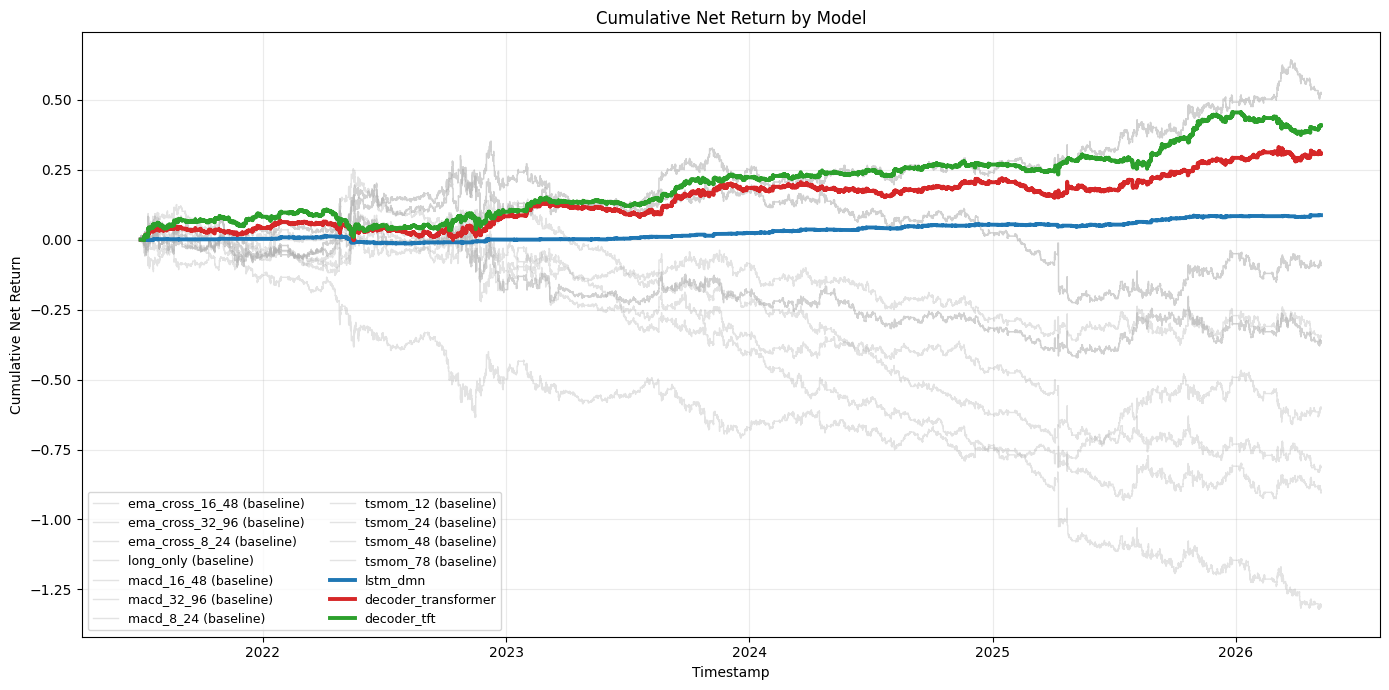

In [3]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',            # blue
    'decoder_transformer': '#d62728', # red
    'decoder_tft': '#2ca02c',         # green
}

plt.figure(figsize=(14, 7))

# plot non-focus first (background)
for model_name, g in pred.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

# plot focus on top
for model_name in focus_models:
    g = pred[pred['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color=focus_colors.get(model_name, None),
        linewidth=2.8, alpha=1.0,
        label=model_name
    )

plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

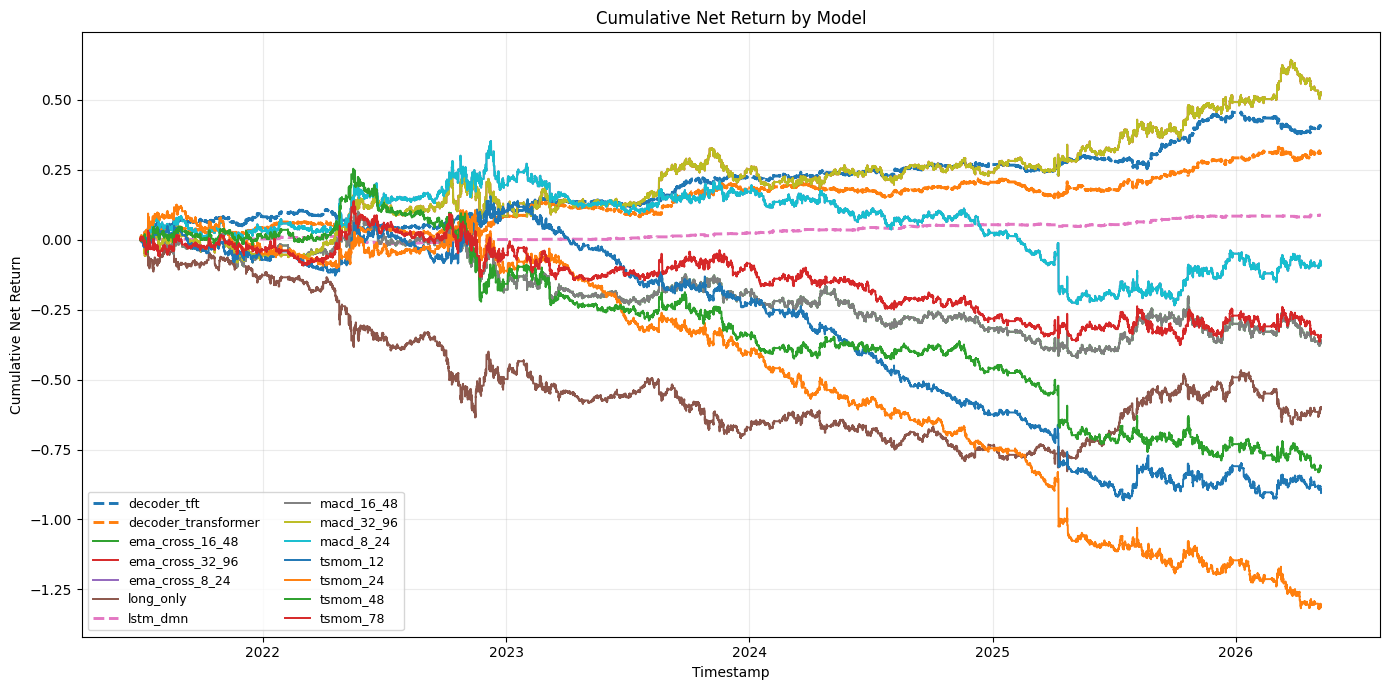

In [4]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

,days,mean_daily_cost,median_daily_cost,p95_daily_cost,max_daily_cost,total_cost
model,,,,,,
tsmom_12,1200,190004.915157,186242.386000,315197.939800,444303.104000,2.280059e+08
tsmom_24,1200,145409.802720,133537.672000,288771.716400,473358.612000,1.744918e+08
tsmom_48,1200,93834.007730,66363.200000,242856.795800,501486.856000,1.126008e+08
macd_8_24,1200,89967.157790,79092.224000,169831.211600,279350.848000,1.079606e+08
ema_cross_8_24,1200,89967.157790,79092.224000,169831.211600,279350.848000,1.079606e+08
tsmom_78,1200,81391.620650,62315.618000,209200.470000,374137.808000,9.766994e+07
decoder_transformer,1200,67257.634737,67512.385950,109900.078059,247781.114079,8.070916e+07
macd_16_48,1200,62139.196417,61216.058000,134004.892600,231130.060000,7.456704e+07
ema_cross_16_48,1200,62139.196417,61216.058000,134004.892600,231130.060000,7.456704e+07


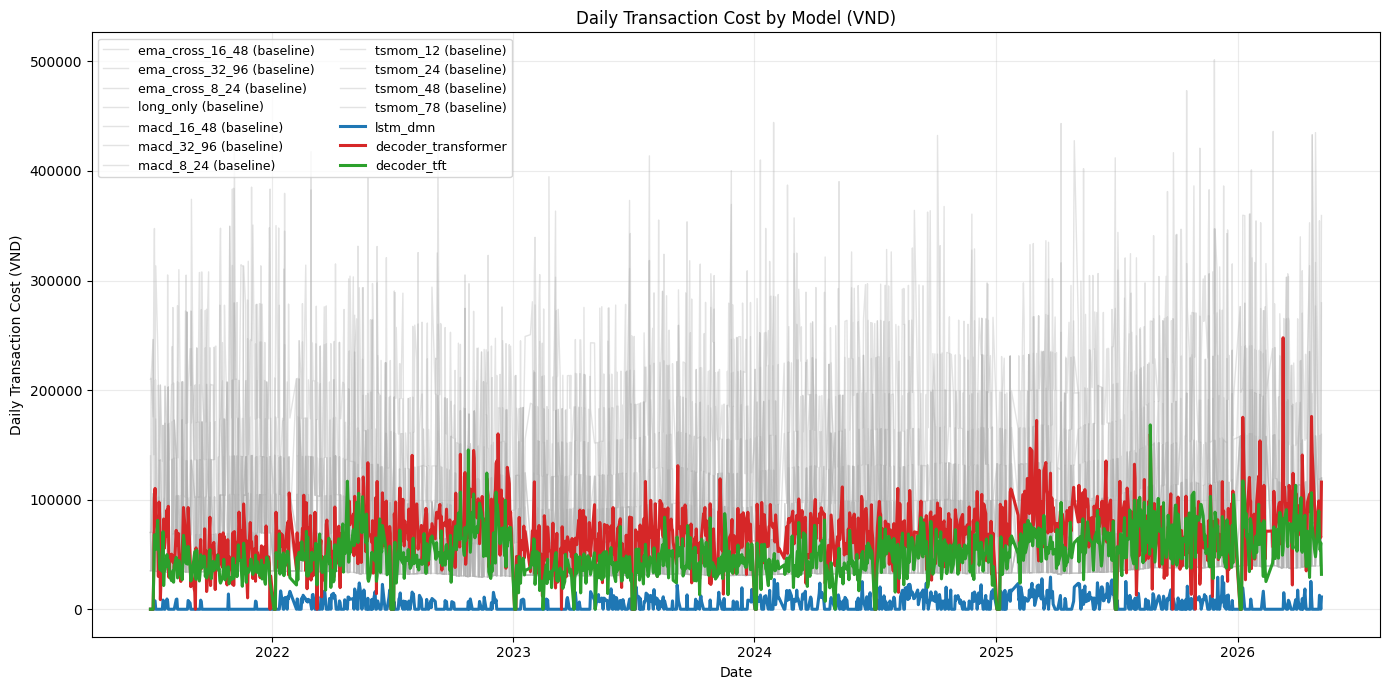

In [5]:
import numpy as np
from pathlib import Path

if 'PROJ' not in globals():
    if 'OUT' in globals():
        PROJ = OUT.parents[1]
    else:
        PROJ = Path.cwd().resolve().parent

px = pd.read_parquet(PROJ / 'data' / 'features' / 'features_5min.parquet')[['timestamp', 'close']]
cost_df = pred[['timestamp', 'model', 'position']].merge(px, on='timestamp', how='left')
cost_df = cost_df.sort_values(['model', 'timestamp']).copy()

contract_multiplier = 100000
margin_rate = 0.1848
transfer_tax_rate = 0.001
fixed_fee_per_side = 5000 + 2700 + 2700

cost_df['prev_pos'] = cost_df.groupby('model')['position'].shift(1).fillna(0.0)
cost_df['buy_units'] = (cost_df['position'] - cost_df['prev_pos']).clip(lower=0.0)
cost_df['sell_units'] = (cost_df['prev_pos'] - cost_df['position']).clip(lower=0.0)

cost_df['tax_vnd_per_contract'] = (
    margin_rate * contract_multiplier * transfer_tax_rate * cost_df['close'] / 2.0
)
cost_df['buy_cost_vnd'] = cost_df['buy_units'] * fixed_fee_per_side
cost_df['sell_fixed_cost_vnd'] = cost_df['sell_units'] * fixed_fee_per_side
cost_df['sell_tax_cost_vnd'] = cost_df['sell_units'] * cost_df['tax_vnd_per_contract']
cost_df['tx_cost_vnd'] = cost_df['buy_cost_vnd'] + cost_df['sell_fixed_cost_vnd'] + cost_df['sell_tax_cost_vnd']
cost_df['date'] = cost_df['timestamp'].dt.date

daily_cost = cost_df.groupby(['model', 'date'], as_index=False)['tx_cost_vnd'].sum()
daily_cost_stats = (
    daily_cost.groupby('model')['tx_cost_vnd']
    .agg(
        days='count',
        mean_daily_cost='mean',
        median_daily_cost='median',
        p95_daily_cost=lambda s: s.quantile(0.95),
        max_daily_cost='max',
        total_cost='sum',
    )
    .sort_values('total_cost', ascending=False)
)

display(daily_cost_stats)

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',
    'decoder_transformer': '#d62728',
    'decoder_tft': '#2ca02c',
}

daily_cost = daily_cost.sort_values(['model', 'date'])
daily_cost['date'] = pd.to_datetime(daily_cost['date'])

plt.figure(figsize=(14, 7))
for model_name, g in daily_cost.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

for model_name in focus_models:
    g = daily_cost[daily_cost['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color=focus_colors.get(model_name, None),
        linewidth=2.2, alpha=1.0,
        label=model_name
    )

plt.title('Daily Transaction Cost by Model (VND)')
plt.xlabel('Date')
plt.ylabel('Daily Transaction Cost (VND)')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [6]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png


In [7]:
import numpy as np

pred_path = OUT / 'predictions' / 'all_predictions.csv'
daily_out_path = OUT / 'tables' / 'daily_metrics_summary.csv'

pred = pd.read_csv(pred_path, parse_dates=['timestamp'])
pred['date'] = pred['timestamp'].dt.normalize()

daily_returns = (
    pred.groupby(['model', 'date'], as_index=False)['net_return']
        .sum()
        .sort_values(['model', 'date'])
)

rows = []
for model_name, g in daily_returns.groupby('model'):
    r = g['net_return'].astype(float)
    n_days = len(r)
    if n_days == 0:
        continue

    total_return = float((1.0 + r).prod() - 1.0)
    annualized_return = float((1.0 + total_return) ** (252.0 / n_days) - 1.0) if total_return > -1.0 else np.nan
    vol = float(r.std(ddof=1)) if n_days > 1 else np.nan
    annualized_volatility = float(vol * np.sqrt(252.0)) if pd.notna(vol) else np.nan
    sharpe_ratio = float((r.mean() / vol) * np.sqrt(252.0)) if pd.notna(vol) and vol > 0 else np.nan
    downside = r[r < 0].std(ddof=1)
    sortino_ratio = float((r.mean() / downside) * np.sqrt(252.0)) if pd.notna(downside) and downside > 0 else np.nan

    equity = (1.0 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_drawdown = float(drawdown.min())
    calmar_ratio = float(annualized_return / abs(max_drawdown)) if pd.notna(annualized_return) and pd.notna(max_drawdown) and max_drawdown < 0 else np.nan

    rows.append({
        'model': model_name,
        'n_days': int(n_days),
        'total_return': total_return,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        'positive_day_rate': float((r > 0).mean()),
        'average_daily_return': float(r.mean()),
        'best_day_return': float(r.max()),
        'worst_day_return': float(r.min()),
    })

daily_summary = pd.DataFrame(rows).sort_values(['sharpe_ratio', 'annualized_return'], ascending=[False, False])
daily_summary.to_csv(daily_out_path, index=False)
print('Saved:', daily_out_path)
daily_summary


Saved: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\tables\daily_metrics_summary.csv


,model,n_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,positive_day_rate,average_daily_return,best_day_return,worst_day_return
6,lstm_dmn,1200,0.090974,0.018453,0.013373,1.374026,1.342521,-0.025488,0.723982,0.210833,0.000073,0.006764,-0.009215
0,decoder_tft,1200,0.486943,0.086880,0.070226,1.221531,1.894969,-0.086775,1.001211,0.468333,0.000340,0.030454,-0.031206
1,decoder_transformer,1200,0.346975,0.064549,0.067676,0.958130,1.555609,-0.065509,0.985347,0.434167,0.000257,0.026521,-0.021564
3,ema_cross_32_96,1200,0.558923,0.097724,0.181327,0.604736,0.871409,-0.159795,0.611559,0.489167,0.000435,0.068693,-0.073057
8,macd_32_96,1200,0.558923,0.097724,0.181327,0.604736,0.871409,-0.159795,0.611559,0.489167,0.000435,0.068693,-0.073057
4,ema_cross_8_24,1200,-0.170115,-0.038401,0.196861,-0.098722,-0.125736,-0.462756,-0.082984,0.470833,-0.000077,0.066586,-0.173966
9,macd_8_24,1200,-0.170115,-0.038401,0.196861,-0.098722,-0.125736,-0.462756,-0.082984,0.470833,-0.000077,0.066586,-0.173966
13,tsmom_78,1200,-0.344790,-0.084960,0.180679,-0.401215,-0.605966,-0.430607,-0.197304,0.445000,-0.000288,0.060822,-0.052699
2,ema_cross_16_48,1200,-0.361030,-0.089771,0.183773,-0.420028,-0.625468,-0.429569,-0.208979,0.445000,-0.000306,0.066586,-0.063630
7,macd_16_48,1200,-0.361030,-0.089771,0.183773,-0.420028,-0.625468,-0.429569,-0.208979,0.445000,-0.000306,0.066586,-0.063630


In [ ]:
import subprocess
import sys
from pathlib import Path

RUN_LABEL = 'vn30f1m_outputs_version1'
PROJECT_ROOT = Path.cwd().resolve().parent
cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'generate_daily_transactions_last_10_days.py'),
    '--run-label', RUN_LABEL,
    '--model', 'decoder_tft',
    '--num-days', '10',
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)
print('Saved:', PROJECT_ROOT / 'outputs' / RUN_LABEL / 'tables' / 'daily_transactions_last_10_days.csv')
print('Saved:', PROJECT_ROOT / 'outputs' / RUN_LABEL / 'tables' / 'daily_transaction_summary_last_10_days.csv')
